# Le simulateur décrit-il la réalité ?

Le projet entraîne un modèle sur des cycles simulés et le valide sur ces mêmes cycles.
Il a aussi mesuré des choses sur les essais NIST. **Il n'avait jamais confronté les deux.**

Trois protocoles, cinq classes, les mêmes résidus, le même `Random Forest` en `Pipeline` :

| | Ce que ça mesure |
|---|---|
| Simulé → simulé (hold-out) | la borne haute, chez lui |
| **Simulé → mesuré** | **la question de X5** |
| Mesuré → mesuré (LOMO) | ce qu'un modèle entraîné sur du réel obtient |

Sans le troisième, un transfert à 0,45 ne dit pas si le simulateur est mauvais ou si la tâche est dure.

En mode froid l'unité extérieure est le condenseur. `CF` (obstruction du serpentin extérieur) → `Condenser_Fouling`, pas l'évaporateur. `LL` est exclu (non modélisé). `Evaporator_Fouling` et `Condenser_Fan_Fault` sont exclus de l'entraînement (absents de NIST).

Pression d'aspiration : `1701_ODVapSV_psia`, jamais `1710`. `EF` / `CF` / `LL` / `UC/OC` / `NF` ne sont pas des features. Résidus NIST : kNN k=5 médiane, essais sains de la **machine cible** (protocole X3).

> Données non versionnées : `data/nist/fdd_1416seer.xlsx`.
> Calcul : `EDA/x5_compute.py`. Ce notebook recharge la table et revérifie l'écrêtage.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'EDA'))

from x5_compute import (
    TABLE, PERCLASS, FIG, clip_probe, safe_T_source_hi,
    T_SOURCE_SPEC, T_SOURCE_NIST_MAX, NIST_TO_SIM, DCOLS,
)
from tools.results import value
from src.physics.simulator import HeatPumpSimulator

assert TABLE.exists(), 'lancer python EDA/x5_compute.py depuis la racine'
tab = pd.read_csv(TABLE)
per = pd.read_csv(PERCLASS)
print(tab.to_string(index=False))


protocol     reference  accuracy   ci_low  ci_high       f1  majority    n
 sim2sim     simulated  0.920667 0.905890 0.933294 0.917208  0.400000 1500
sim2real measured-knn5  0.453619 0.435403 0.471960 0.342917  0.281096 2846
    lomo measured-knn5  0.667955 0.650436 0.685021 0.596432  0.281096 2846


## L'écrêtage, mesuré — pas supposé

Le simulateur cappe `T_evap` à 20 °C. Relever cette borne changerait la physique et invaliderait le volet simulé. On restreint le domaine. Le brief plaçait le cap à `T_source = 27 °C` ; il faut le vérifier.


In [2]:
probe = clip_probe()
print(probe.to_string(index=False))
hi = safe_T_source_hi()
print(f'\nT_source max sans écrêtage (sain) : {hi:.1f} °C  — spec {T_SOURCE_SPEC[1]} °C')
assert probe.loc[probe.T_source == 24.0, 'clipped'].iloc[0] == False
assert probe.loc[probe.T_source == 25.0, 'clipped'].iloc[0] == True
print('Le cap est atteint dès 25 °C, pas 27.')

sim = HeatPumpSimulator()
r = sim.simulate_cycle(24.0, 35.0, 1.0)
print(f'\nSimulé 24/35 °C : P_evap={r.P_evap:.2f}  P_cond={r.P_cond:.2f}  τ={r.P_cond/r.P_evap:.2f}  COP={r.COP:.2f}')
print('NIST sain publié :              10,5                  25,7                  2,37                 3,41')


 T_source  T_sink  T_evap  clipped    P_evap    P_cond      tau      COP
     20.0    35.0    15.0    False 12.542895 24.186085 1.928270 3.812978
     24.0    35.0    19.0    False 14.036001 24.186085 1.723147 4.319810
     25.0    35.0    20.0     True 14.429274 24.186085 1.676182 4.476779
     26.0    35.0    20.0     True 14.429274 24.186085 1.676182 4.476779
     27.0    35.0    20.0     True 14.429274 24.186085 1.676182 4.476779
     30.0    35.0    20.0     True 14.429274 24.186085 1.676182 4.476779

T_source max sans écrêtage (sain) : 24.9 °C  — spec 26.0 °C
Le cap est atteint dès 25 °C, pas 27.

Simulé 24/35 °C : P_evap=14.04  P_cond=24.19  τ=1.72  COP=4.32
NIST sain publié :              10,5                  25,7                  2,37                 3,41


## Cinq classes se correspondent

| NIST | Simulateur |
|---|---|
| `NF` | `Normal` |
| `CF` — obstruction extérieure | `Condenser_Fouling` |
| `EF` — débit d'air intérieur | `Evaporator_Fan_Fault` |
| `UC` | `Refrigerant_Undercharge` |
| `OC` | `Refrigerant_Overcharge` |
| `LL` | *exclu — non modélisé* |


In [3]:
import pandas as pd
from x3_compute import load

df0 = pd.read_excel(ROOT / 'data' / 'nist' / 'fdd_1416seer.xlsx')
F2C = lambda s: (s - 32) * 5 / 9
ts_all = F2C(df0['Inlet TC Grid AVG Temp (F)'])
n_cap = int((ts_all <= T_SOURCE_NIST_MAX).sum())
print(f'T_source ≤ {T_SOURCE_NIST_MAX:.0f} °C : {n_cap} / {len(df0)} ({n_cap/len(df0):.1%})')
assert n_cap == 4356

X, y, grp = load()
print('X3 (6 classes, dont LL) :', len(X), dict(y.value_counts()))
print('correspondance :', NIST_TO_SIM)
print('résidus du classifieur :', DCOLS)


T_source ≤ 26 °C : 4356 / 7375 (59.1%)


X3 (6 classes, dont LL) : 5386 {'No_Fault': np.int64(1352), 'Undercharge': np.int64(1228), 'Overcharge': np.int64(942), 'Evap_Airflow': np.int64(774), 'LiquidLine': np.int64(593), 'Cond_Blockage': np.int64(497)}
correspondance : {'No_Fault': 'Normal', 'Cond_Blockage': 'Condenser_Fouling', 'Evap_Airflow': 'Evaporator_Fan_Fault', 'Undercharge': 'Refrigerant_Undercharge', 'Overcharge': 'Refrigerant_Overcharge'}
résidus du classifieur : ['d_T_discharge', 'd_superheat', 'd_subcooling', 'd_COP', 'd_W_comp']


## Les trois protocoles

Jeu simulé : 5000 cycles, `T_source ∈ [14, 24,9]`, `T_sink ∈ [19, 48]`, vitesse 1,0, cinq classes, sévérités de production. `generator.py` n'est pas modifié — les plages sont passées en paramètres. Aucun `T_evap` généré n'est à 20,0.

Le modèle livré et le jeu de production ne sont pas touchés.


In [4]:
def pct(protocol, metric='accuracy'):
    proto = {'sim2sim': 'holdout-test', 'sim2real': 'sim2real', 'lomo': 'LOMO'}[protocol]
    ref = 'simulated' if protocol == 'sim2sim' else 'measured-knn5'
    return value(
        experiment='X5', protocol=proto, reference=ref,
        features='residuals', model='random-forest',
        metric=metric, label='__global__',
    )

s2s = pct('sim2sim')
s2r = pct('sim2real')
lomo = pct('lomo')
print(f'simulé → simulé   {s2s:.3f}')
print(f'simulé → mesuré   {s2r:.3f}')
print(f'mesuré → mesuré   {lomo:.3f}')
assert abs(s2s - float(tab.loc[tab.protocol=='sim2sim', 'accuracy'].iloc[0])) < 1e-6
assert s2r < lomo, 'le transfert ne peut pas battre le LOMO si le simulateur est le maillon faible'
assert s2r > float(tab.loc[tab.protocol=='sim2real', 'majority'].iloc[0])

print('\npar classe (F1)')
print(per.pivot(index='label', columns='protocol', values='f1').round(3).to_string())


simulé → simulé   0.921
simulé → mesuré   0.454
mesuré → mesuré   0.668

par classe (F1)
protocol                  LOMO  holdout-test  sim2real
label                                                 
Condenser_Fouling        0.317         0.749     0.000
Evaporator_Fan_Fault     0.400         0.998     0.031
Normal                   0.808         0.930     0.716
Refrigerant_Overcharge   0.542         0.936     0.522
Refrigerant_Undercharge  0.915         0.974     0.445


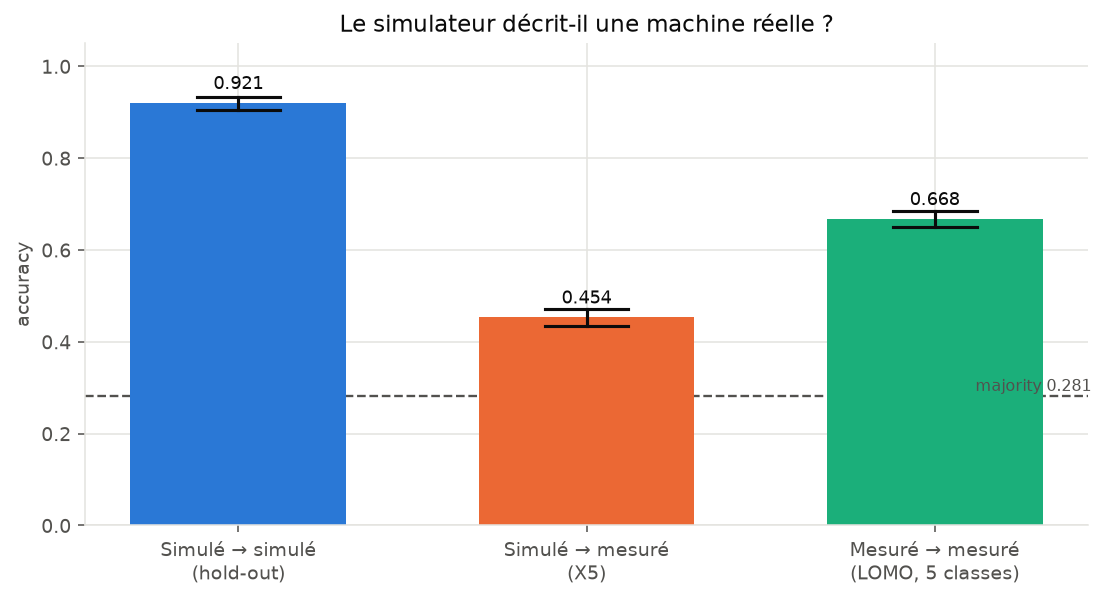

In [5]:
display(Image(filename=str(FIG)))


## Verdict

**Non : le simulateur décrit son propre cycle, pas une machine réelle.**

Chez lui, 0,921 [0,906 – 0,933]. Sur les essais mesurés, 0,454 [0,435 – 0,472] — au-dessus de la classe majoritaire (0,281), très en-dessous du LOMO à 0,668 [0,650 – 0,685]. L'écart 0,668 − 0,454 est le coût du simulateur. Sans le LOMO on aurait pu croire que cinq classes c'est simplement dur.

La charge passe en partie (surcharge F1 0,52, sous-charge 0,45). L'obstruction condenseur et le débit intérieur, non (0,00 et 0,03) — déjà les classes dures en LOMO (0,32 et 0,40).

Le simulateur sert à démontrer et à explorer. Il n'entraîne pas un détecteur destiné au terrain.
